In [13]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [14]:
base_path = "/content/drive/MyDrive/inbody.v1i.yolov8-obb/inbody.v1i.yolov8-obb"

In [3]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 70.4 MB/s eta 0:00:00


In [4]:
import os
import cv2
import yaml
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO
import random
from collections import Counter

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [5]:
import os
os.listdir(base_path)


['data.yaml',
 'README.dataset.txt',
 'README.roboflow.txt',
 'valid',
 'test',
 'train']

In [6]:
os.listdir(base_path + "/train")[:10]

['labels', 'images']

In [15]:
base_path = "/content/drive/MyDrive/inbody.v1i.yolov8-obb/inbody.v1i.yolov8-obb"



In [16]:
with open(base_path + "/data.yaml") as f:
    data = yaml.safe_load(f)

print("Classes:")
print(data["names"])

Classes:
{0: 'inbody_composition', 1: 'inbody_composition_history', 2: 'inbody_composition_report', 3: 'inbody_exercise', 4: 'inbody_impedance', 5: 'inbody_info', 6: 'inbody_muscle', 7: 'inbody_obesity', 8: 'inbody_qrcode', 9: 'inbody_score', 10: 'inbody_segmental', 11: 'inbody_segmental_2'}


In [17]:
train_images = os.listdir(base_path + "/train/images")
valid_images = os.listdir(base_path + "/valid/images")
test_images = os.listdir(base_path + "/test/images")

print("Train:", len(train_images))
print("Validation:", len(valid_images))
print("Test:", len(test_images))

Train: 421
Validation: 119
Test: 60


(np.float64(-0.5), np.float64(639.5), np.float64(639.5), np.float64(-0.5))

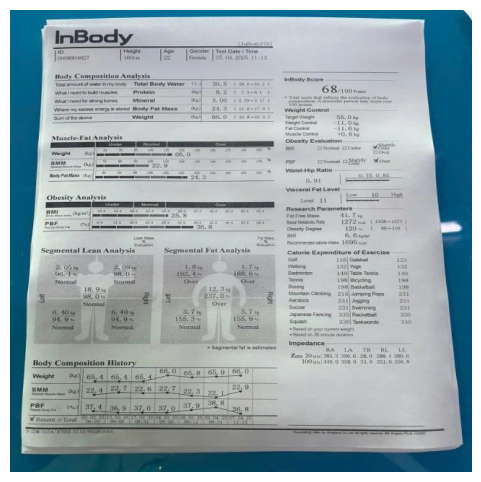

In [18]:
img_path = base_path + "/train/images/" + train_images[0]

img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6,6))
plt.imshow(img)
plt.axis("off")

In [19]:
def read_yolo_labels(label_path):
    boxes = []

    if not os.path.exists(label_path):
        return boxes

    with open(label_path, "r") as f:
        lines = f.readlines()

    for line in lines:
        parts = line.strip().split()

        class_id = int(parts[0])
        x_center = float(parts[1])
        y_center = float(parts[2])
        width = float(parts[3])
        height = float(parts[4])

        boxes.append((class_id, x_center, y_center, width, height))

    return boxes

In [20]:
def yolo_to_bbox(x_center, y_center, width, height, img_w, img_h):

    x1 = int((x_center - width/2) * img_w)
    y1 = int((y_center - height/2) * img_h)
    x2 = int((x_center + width/2) * img_w)
    y2 = int((y_center + height/2) * img_h)

    return x1, y1, x2, y2

In [21]:
def show_image_with_boxes(image_path, label_path, class_names):

    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    h, w, _ = img.shape

    boxes = read_yolo_labels(label_path)

    for box in boxes:

        class_id, x_center, y_center, width, height = box

        x1, y1, x2, y2 = yolo_to_bbox(x_center, y_center, width, height, w, h)

        cv2.rectangle(img, (x1, y1), (x2, y2), (0,255,0), 2)

        label = class_names[class_id]

        cv2.putText(img, label, (x1, y1-10),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.6,
                    (0,255,0),
                    2)

    plt.figure(figsize=(8,8))
    plt.imshow(img)
    plt.axis("off")

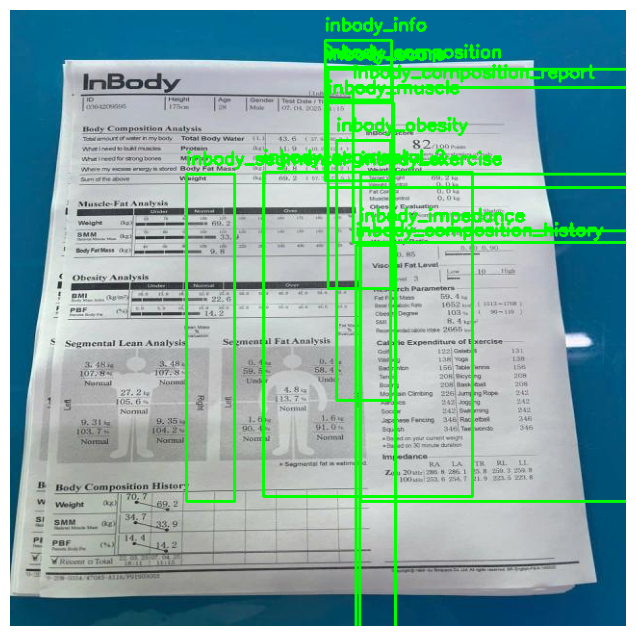

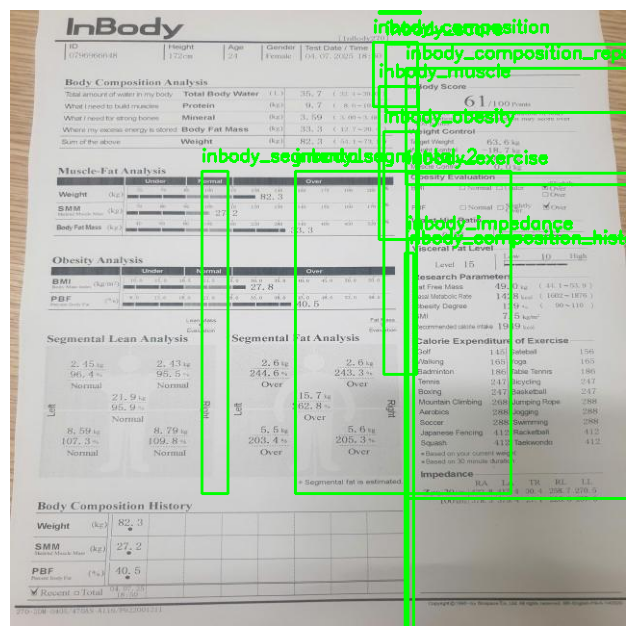

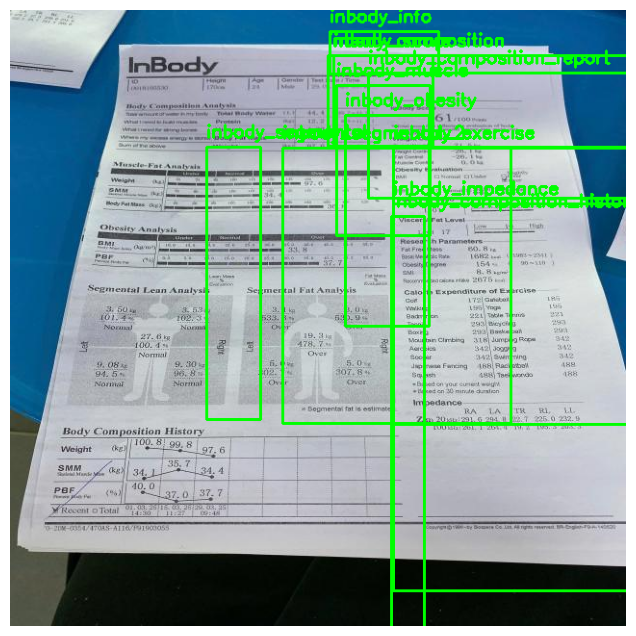

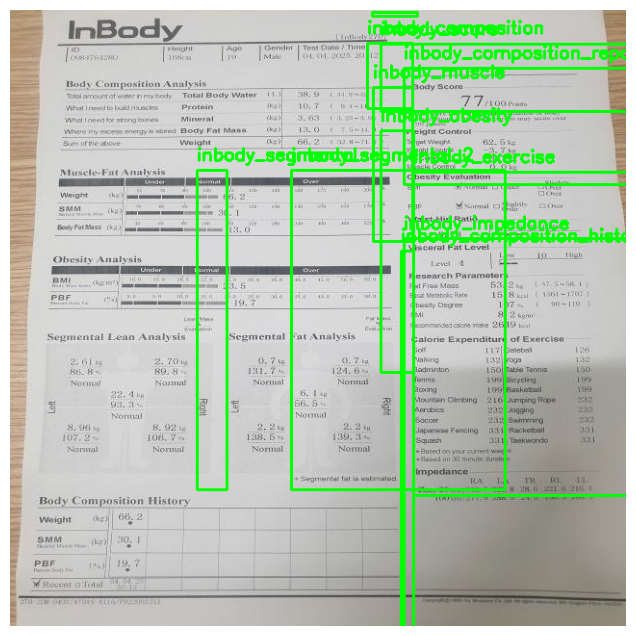

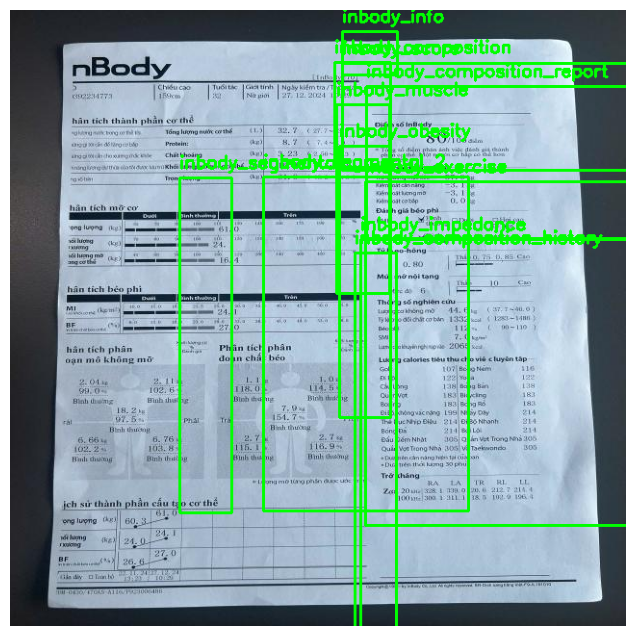

In [22]:
class_names = data["names"]

images_folder = base_path + "/train/images"
labels_folder = base_path + "/train/labels"

image_files = sorted(os.listdir(images_folder))[:5]

for img_file in image_files:

    img_path = os.path.join(images_folder, img_file)

    label_file = img_file.replace(".jpg", ".txt")
    label_path = os.path.join(labels_folder, label_file)

    show_image_with_boxes(img_path, label_path, class_names)

In [23]:
label_path = base_path + "/train/labels/" + os.listdir(base_path + "/train/labels")[0]

with open(label_path) as f:
    print(f.readline())

2 0.8890625 0.2296875000000001 0.6125 0.2296875000000001 0.6125 0.5484375000000001 0.8890625 0.5484375000000001



In [24]:
def read_obb_labels(label_path):

    boxes = []

    if not os.path.exists(label_path):
        return boxes

    with open(label_path) as f:
        lines = f.readlines()

    for line in lines:

        parts = line.strip().split()

        class_id = int(parts[0])
        coords = list(map(float, parts[1:]))

        boxes.append((class_id, coords))

    return boxes

In [25]:
def show_image_with_obb(image_path, label_path, class_names):

    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    h, w, _ = img.shape

    boxes = read_obb_labels(label_path)

    for box in boxes:

        class_id, coords = box

        points = []

        for i in range(0, len(coords), 2):

            x = int(coords[i] * w)
            y = int(coords[i+1] * h)

            points.append([x,y])

        points = np.array(points)

        cv2.polylines(img, [points], True, (0,255,0), 2)

        label = class_names[class_id]

        cv2.putText(img, label,
                    (points[0][0], points[0][1]-10),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.6,
                    (0,255,0),
                    2)

    plt.figure(figsize=(8,8))
    plt.imshow(img)
    plt.axis("off")

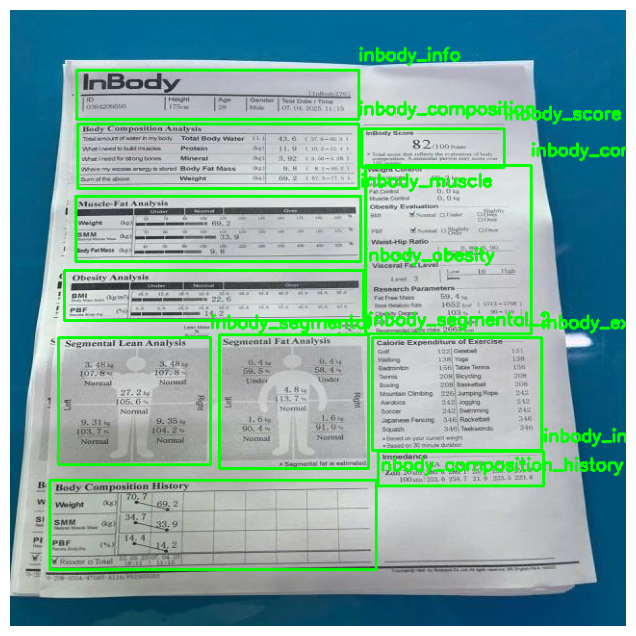

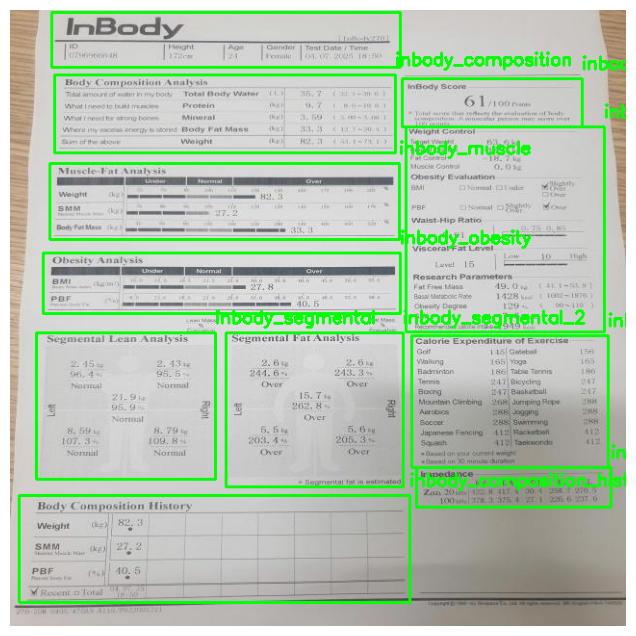

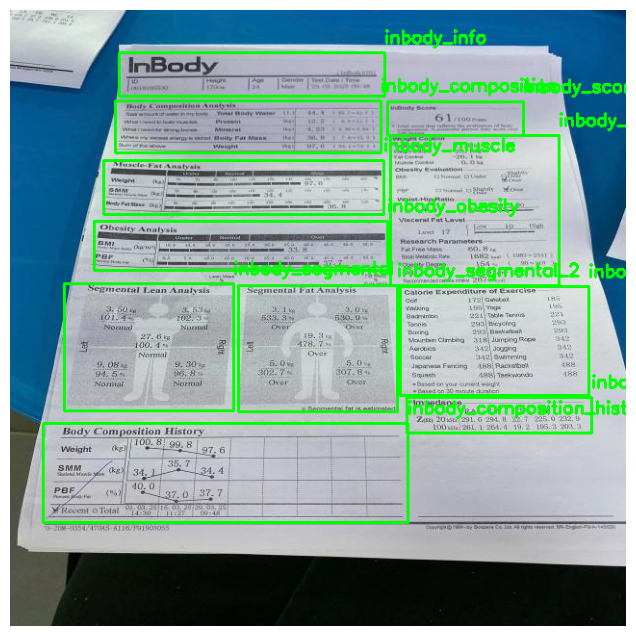

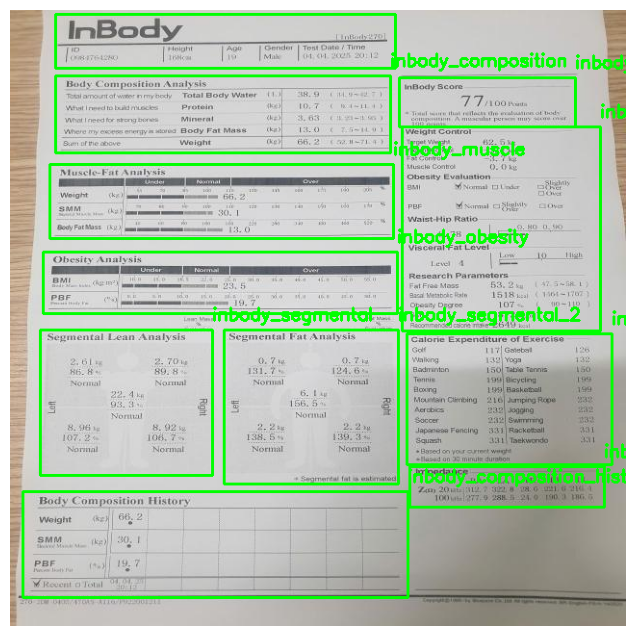

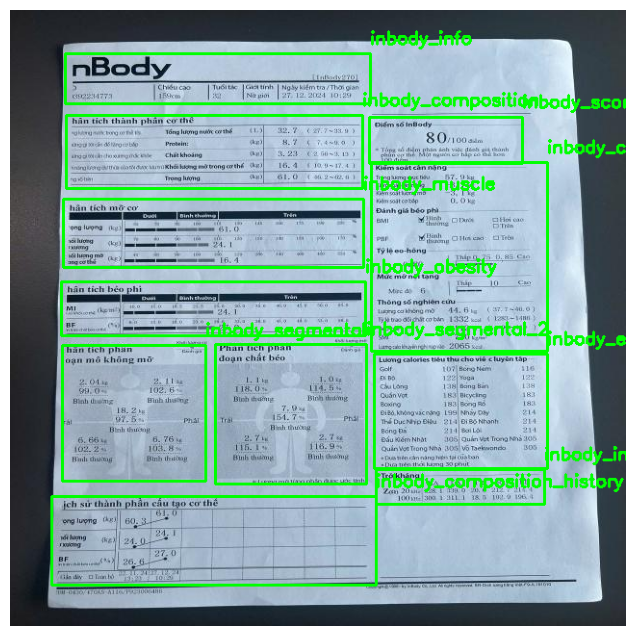

In [26]:
class_names = data["names"]

images_folder = base_path + "/train/images"
labels_folder = base_path + "/train/labels"

image_files = sorted(os.listdir(images_folder))[:5]

for img_file in image_files:

    img_path = os.path.join(images_folder, img_file)

    label_file = img_file.replace(".jpg", ".txt")
    label_path = os.path.join(labels_folder, label_file)

    show_image_with_obb(img_path, label_path, class_names)

In [27]:
from collections import Counter

class_counts = Counter()

labels_folder = base_path + "/train/labels"

for file in os.listdir(labels_folder):

    label_path = os.path.join(labels_folder, file)

    with open(label_path) as f:
        lines = f.readlines()

    for line in lines:

        class_id = int(line.split()[0])
        class_counts[class_id] += 1

print(class_counts)

Counter({4: 422, 2: 421, 3: 421, 10: 421, 11: 421, 1: 421, 7: 421, 0: 421, 6: 421, 9: 421, 5: 421, 8: 72})


In [28]:
print(data["names"][8])

inbody_qrcode


In [29]:
for class_id, count in sorted(class_counts.items()):
    print(f"{data['names'][class_id]} : {count}")

inbody_composition : 421
inbody_composition_history : 421
inbody_composition_report : 421
inbody_exercise : 421
inbody_impedance : 422
inbody_info : 421
inbody_muscle : 421
inbody_obesity : 421
inbody_qrcode : 72
inbody_score : 421
inbody_segmental : 421
inbody_segmental_2 : 421


In [30]:
boxes_per_image = []

labels_folder = base_path + "/train/labels"

for file in os.listdir(labels_folder):

    label_path = os.path.join(labels_folder, file)

    with open(label_path) as f:
        lines = f.readlines()

    boxes_per_image.append(len(lines))

print("Min boxes:", min(boxes_per_image))
print("Max boxes:", max(boxes_per_image))
print("Average boxes:", sum(boxes_per_image)/len(boxes_per_image))

Min boxes: 11
Max boxes: 12
Average boxes: 11.173396674584323


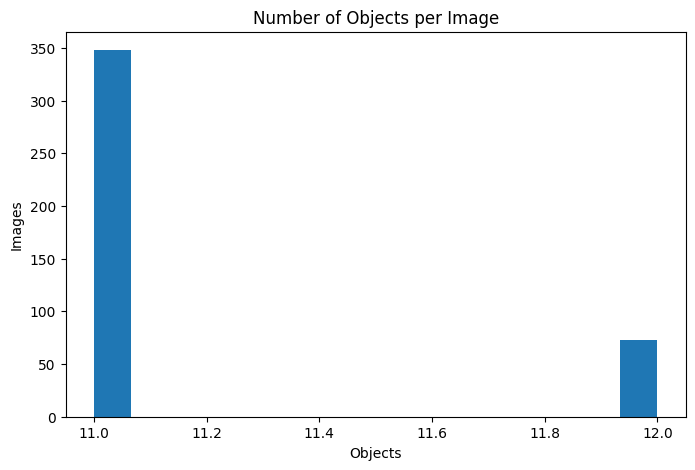

In [31]:
plt.figure(figsize=(8,5))
plt.hist(boxes_per_image, bins=15)

plt.title("Number of Objects per Image")
plt.xlabel("Objects")
plt.ylabel("Images")

plt.show()

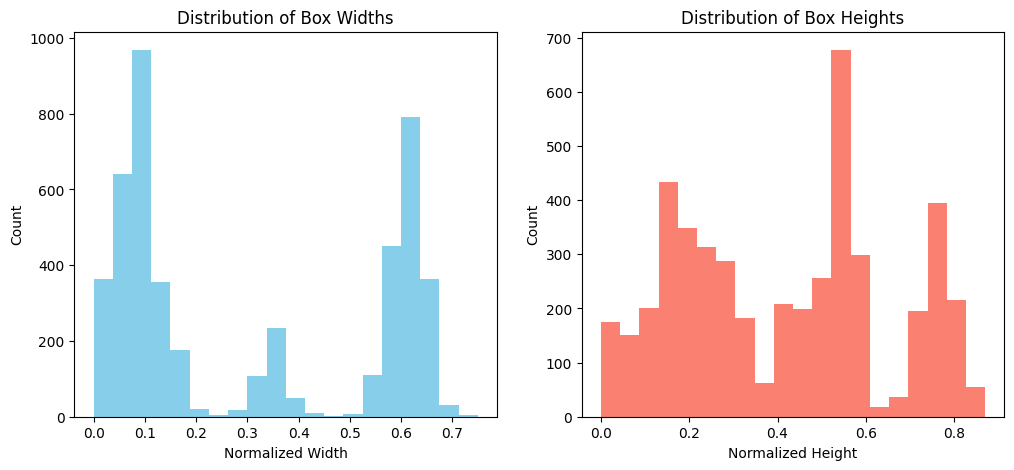

In [32]:
labels_folder = base_path + "/train/labels"

widths = []
heights = []

for file in os.listdir(labels_folder):
    label_path = os.path.join(labels_folder, file)
    with open(label_path) as f:
        for line in f:
            parts = line.strip().split()
            # YOLO format: class x_center y_center w h (normalized)
            w = float(parts[3])
            h = float(parts[4])
            widths.append(w)
            heights.append(h)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.hist(widths, bins=20, color='skyblue')
plt.title("Distribution of Box Widths")
plt.xlabel("Normalized Width")
plt.ylabel("Count")

plt.subplot(1,2,2)
plt.hist(heights, bins=20, color='salmon')
plt.title("Distribution of Box Heights")
plt.xlabel("Normalized Height")
plt.ylabel("Count")

plt.show()

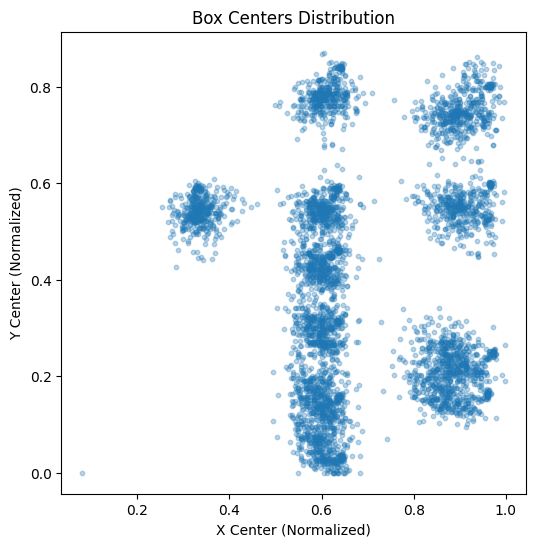

In [33]:
x_centers = []
y_centers = []

for file in os.listdir(labels_folder):
    label_path = os.path.join(labels_folder, file)
    with open(label_path) as f:
        for line in f:
            parts = line.strip().split()
            x_centers.append(float(parts[1]))
            y_centers.append(float(parts[2]))

plt.figure(figsize=(6,6))
plt.scatter(x_centers, y_centers, alpha=0.3, s=10)
plt.title("Box Centers Distribution")
plt.xlabel("X Center (Normalized)")
plt.ylabel("Y Center (Normalized)")
plt.show()

In [35]:

!pip install ultralytics -q
!yolo version

8.4.22


In [40]:
 yaml_path = "/content/drive/MyDrive/inbody.v1i.yolov8-obb/inbody.v1i.yolov8-obb/data.yaml"

print("مسار data.yaml:", yaml_path)

مسار data.yaml: /content/drive/MyDrive/inbody.v1i.yolov8-obb/inbody.v1i.yolov8-obb/data.yaml


In [50]:
from ultralytics import YOLO
model = YOLO("yolov8n-obb.pt")

In [51]:
model.train(
    data=yaml_path,         # ملف البيانات
    epochs=35,
    imgsz=640,
    batch=8,
    project="/content/drive/MyDrive/inbody.v1i.yolov8-obb",
    name="inbody1_model",
    device=0,
    save=True               # دي مهمة جداً عشان YOLO يحفظ best.pt و last.pt
)

Ultralytics 8.4.22 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/inbody.v1i.yolov8-obb/inbody.v1i.yolov8-obb/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=35, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-obb.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=inbody1_model, nbs=64, nms=False, opset=None, optimize=False, optim

ultralytics.utils.metrics.OBBMetrics object with attributes:

ap_class_index: array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7847a1419160>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,  

In [52]:
import os

path = "/content/drive/MyDrive/inbody.v1i.yolov8-obb/inbody1_model/"
os.listdir(path)

['weights',
 'args.yaml',
 'labels.jpg',
 'train_batch0.jpg',
 'train_batch1.jpg',
 'train_batch2.jpg',
 'results.csv',
 'train_batch1325.jpg',
 'train_batch1326.jpg',
 'train_batch1327.jpg',
 'val_batch0_labels.jpg',
 'val_batch0_pred.jpg',
 'val_batch1_pred.jpg',
 'val_batch1_labels.jpg',
 'val_batch2_pred.jpg',
 'val_batch2_labels.jpg',
 'BoxPR_curve.png',
 'BoxF1_curve.png',
 'BoxP_curve.png',
 'BoxR_curve.png',
 'confusion_matrix_normalized.png',
 'confusion_matrix.png',
 'results.png']

In [53]:
import os

weights_path = "/content/drive/MyDrive/inbody.v1i.yolov8-obb/inbody1_model/weights/"
os.listdir(weights_path)

['last.pt', 'best.pt']

In [54]:
best_model_path = "/content/drive/MyDrive/inbody.v1i.yolov8-obb/inbody1_model/weights/best.pt"
print("الموديل النهائي اتخزن هنا:", best_model_path)

الموديل النهائي اتخزن هنا: /content/drive/MyDrive/inbody.v1i.yolov8-obb/inbody1_model/weights/best.pt


In [55]:
from ultralytics import YOLO

# تحميل الموديل
model = YOLO("/content/drive/MyDrive/inbody.v1i.yolov8-obb/inbody1_model/weights/best.pt")

# تقييم الموديل على الـ validation set
metrics = model.val()  # هيرجعلك precision, recall, mAP
print(metrics)

Ultralytics 8.4.22 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8n-obb summary (fused): 82 layers, 3,079,559 parameters, 0 gradients, 8.3 GFLOPs
val: Fast image access ✅ (ping: 4.8±8.8 ms, read: 21.2±16.0 MB/s, size: 69.2 KB)
val: Scanning /content/drive/MyDrive/inbody.v1i.yolov8-obb/inbody.v1i.yolov8-obb/valid/labels.cache... 119 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 119/119 38.4Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 1.1it/s 7.1s
                   all        119       1324      0.999          1      0.995      0.986
    inbody_composition        119        119      0.999          1      0.995      0.993
inbody_composition_history        119        119      0.999          1      0.995      0.984
inbody_composition_report        119        119          1          1      0.995      0.993
       inbody_exercise        119        119      0.999          1      0.995   

In [56]:
from google.colab import files
from PIL import Image

# رفع الصورة
uploaded = files.upload()  # هيفتحلك اختيار الصورة من جهازك

# عرض الصورة المرفوعة
for filename in uploaded.keys():
    img_path = filename
    img = Image.open(img_path)
    img.show()

Saving 770_RS-1.png to 770_RS-1.png



image 1/1 /content/770_RS-1.png: 640x512 1 inbody_composition, 1 inbody_composition_history, 1 inbody_composition_report, 2 inbody_exercises, 1 inbody_info, 1 inbody_muscle, 1 inbody_obesity, 1 inbody_qrcode, 53.5ms
Speed: 3.1ms preprocess, 53.5ms inference, 2.7ms postprocess per image at shape (1, 3, 640, 512)


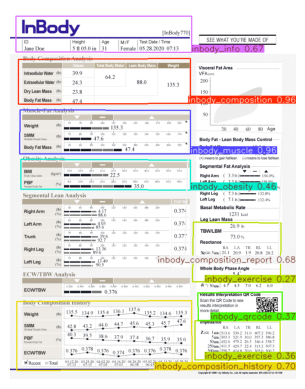

In [57]:
img_path="770_RS-1.png"
results = model(img_path)

# رسم النتائج على الصورة
results[0].plot()  # ده بيرسم البوكسات على الصورة

# عرض الصورة باستخدام matplotlib
plt.imshow(results[0].plot())
plt.axis('off')
plt.show()


In [58]:
from google.colab import files
from PIL import Image

# رفع الصورة
uploaded = files.upload()  # هيفتحلك اختيار الصورة من جهازك

# عرض الصورة المرفوعة
for filename in uploaded.keys():
    img_path = filename
    img = Image.open(img_path)
    img.show()

Saving Screenshot 2026-02-11 153648.png to Screenshot 2026-02-11 153648.png



image 1/1 /content/Screenshot 2026-02-11 153648.png: 352x640 (no detections), 51.4ms
Speed: 2.1ms preprocess, 51.4ms inference, 0.5ms postprocess per image at shape (1, 3, 352, 640)


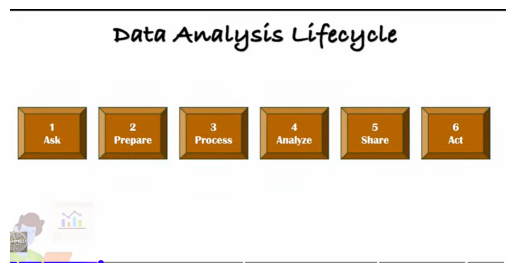

In [59]:
img_path="Screenshot 2026-02-11 153648.png"
results = model(img_path)

# رسم النتائج على الصورة
results[0].plot()  # ده بيرسم البوكسات على الصورة

# عرض الصورة باستخدام matplotlib
plt.imshow(results[0].plot())
plt.axis('off')
plt.show()
